In [8]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from broadcasting.results import load_run, list_runs

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120})

RESULTS_DIR = Path("results")


def latest_run():
    files = sorted(RESULTS_DIR.glob("run_*.json"))
    if not files:
        raise FileNotFoundError("No run files found in results/")
    return load_run(files[-1])


def get_p_list(run):
    """Extract noise values from a run dict."""
    # New simulation format stores p_list in metadata
    p = run.get("metadata", {}).get("p_list") or run.get("p_list")
    if p is None:
        raise KeyError("No p_list found in run — is this a hardware (tau-sweep) result?")
    return np.array(p)


runs = list_runs(RESULTS_DIR)
print(f"Found {len(runs)} run(s) in {RESULTS_DIR}/\n")
for i, r in enumerate(runs):
    qec_str = "QEC" if r.get("use_qec") else "no-QEC"
    mode = r.get("metadata", {}).get("mode", r.get("backend", "?"))
    n_fids = len(r.get("fidelities", []))
    N = r["N"]
    print(f"  [{i}] {r['filename']}: M={r['M']}, N={N}, {qec_str}, "
          f"mode={mode}, {n_fids} noise points")


Found 41 run(s) in results/

  [0] run_20260408_160814.json: M=1, N=2, no-QEC, mode=ibm_kingston, 0 noise points
  [1] run_20260408_161340.json: M=1, N=3, no-QEC, mode=ibm_marrakesh, 0 noise points
  [2] run_20260408_161902.json: M=1, N=4, no-QEC, mode=ibm_marrakesh, 0 noise points
  [3] run_20260408_162212.json: M=2, N=2, no-QEC, mode=ibm_marrakesh, 0 noise points
  [4] run_20260408_162440.json: M=2, N=3, no-QEC, mode=ibm_marrakesh, 0 noise points
  [5] run_20260408_162906.json: M=2, N=4, no-QEC, mode=ibm_fez, 0 noise points
  [6] run_20260408_163129.json: M=3, N=2, no-QEC, mode=ibm_marrakesh, 0 noise points
  [7] run_20260408_170544.json: M=1, N=2, no-QEC, mode=ibm_fez, 0 noise points
  [8] run_20260409_142040.json: M=1, N=2, no-QEC, mode=exact, 50 noise points
  [9] run_20260409_142625.json: M=1, N=2, QEC, mode=sampled (1000 trajectories), 50 noise points
  [10] run_20260416_100341.json: M=1, N=2, QEC, mode=sampled (1000 trajectories), 50 noise points
  [11] run_20260416_105525.json

In [11]:
run = latest_run()
run
# run["fidelities"]

{'filepath': 'results\\run_20260513_144130.json',
 'filename': 'run_20260513_144130.json',
 'timestamp': '2026-05-13T14:41:30.186253',
 'job_id': 'd82c0k6gbeec73aljrq0',
 'backend': 'ibm_marrakesh',
 'shots': 8192,
 'seed': 42,
 'M': 1,
 'N': 2,
 'use_qec': False,
 'nt': 1,
 'theta_samples': [[4.862909272689599]],
 'tau_values': [0,
  150,
  300,
  450,
  600,
  750,
  900,
  1050,
  1200,
  1350,
  1500,
  1650,
  1800,
  1950,
  2100,
  2250,
  2400,
  2550,
  2700,
  2850,
  3000,
  3150,
  3300,
  3450,
  3600,
  3750,
  3900,
  4050,
  4200,
  4350,
  4500,
  4650,
  4800,
  4950,
  5100,
  5250,
  5400,
  5550,
  5700,
  5850,
  6000],
 'entries': [{'theta_idx': 0,
   'thetas': [4.862909272689599],
   'tau': 0,
   'fidelities': [0.9263916015625, 0.767578125],
   'counts': {'10': 1677, '01': 376, '00': 5912, '11': 227}},
  {'theta_idx': 0,
   'thetas': [4.862909272689599],
   'tau': 150,
   'fidelities': [0.9232177734375, 0.9237060546875],
   'counts': {'00': 7140, '11': 202, '01'

In [6]:
# --- Latest run: fidelity vs noise ---

run = latest_run()
N = run["N"]
fids = np.array(run["fidelities"])  # shape (n_p, N)
p_arr = get_p_list(run)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.tab10.colors

for i in range(N):
    ax.plot(p_arr, fids[:, i], "-o", color=colors[i % len(colors)],
            markersize=3, linewidth=1.2, label=f"Receiver {i}")

ax.plot(p_arr, fids.mean(axis=1), "s--", color="black",
        markersize=4, linewidth=1.5, label="Average")
ax.axhline(0.5, color="gray", linestyle=":", alpha=0.5, label="Random (0.5)")

ax.set_xlabel("Depolarizing probability p")
ax.set_ylabel("Fidelity")
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 1)
ax.legend(loc="best", fontsize=9)

# Metadata annotation
meta = run.get("metadata", {})
qec_str = "QEC [[5,1,3]]" if run.get("use_qec") else "No QEC"
mode = meta.get("mode", run.get("backend", "?"))
meta_lines = [
    f"Mode: {mode}",
    f"M={run['M']}, N={N}, {qec_str}",
    f"p points: {len(p_arr)}",
    f"Time: {run.get('timestamp', '')[:19]}",
]
ax.text(0.98, 0.98, "\n".join(meta_lines), transform=ax.transAxes,
        fontsize=7, va="top", ha="right", fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="wheat", alpha=0.7))

ax.set_title(f"Fidelity vs Depolarizing Noise — {run['filename']}")
plt.tight_layout()
plt.show()


KeyError: 'fidelities'

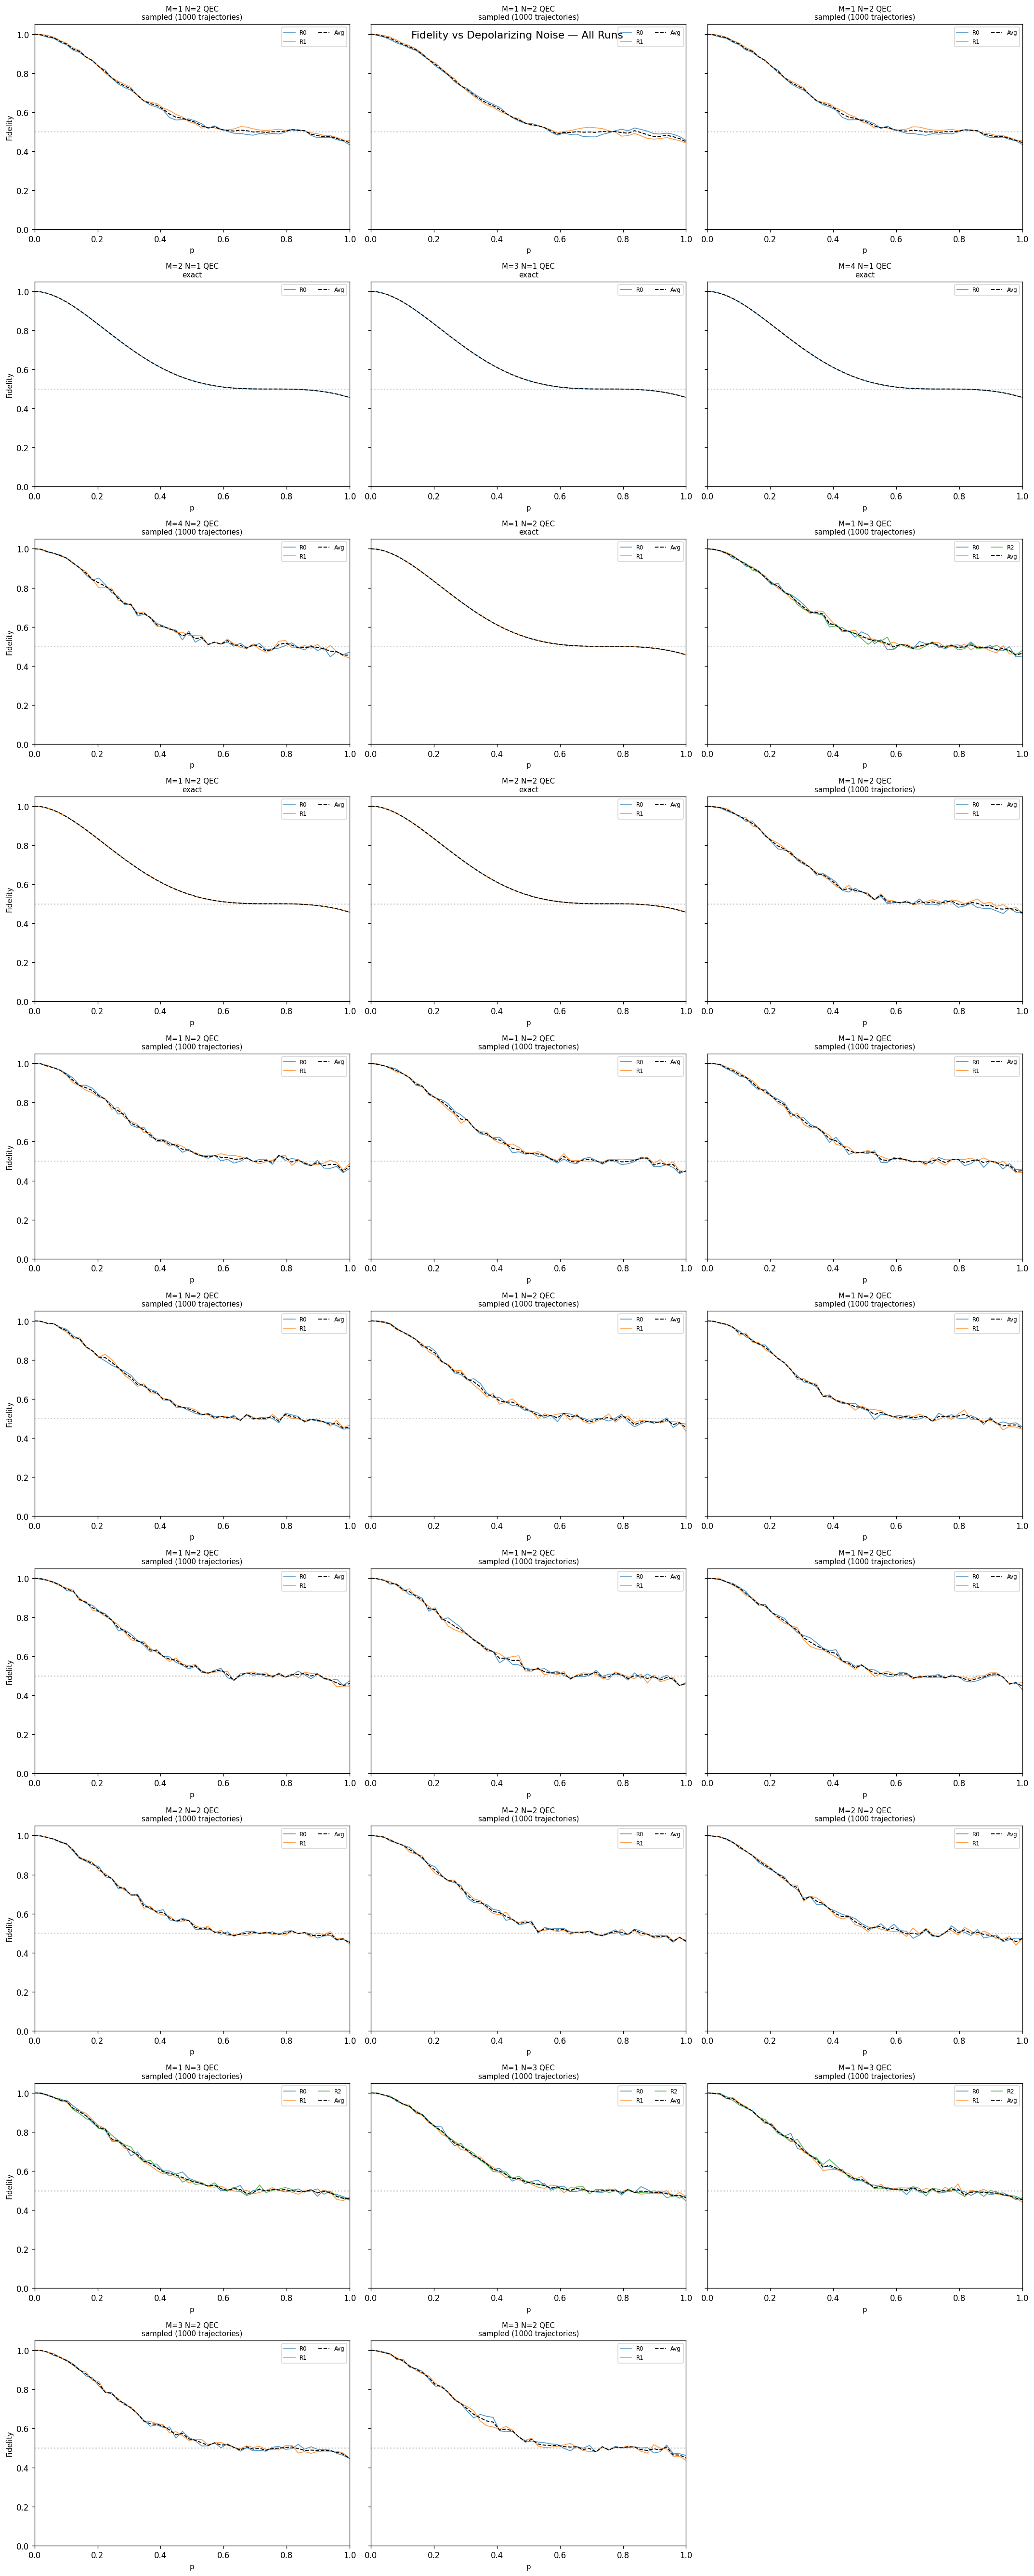


29 run(s) shown:
  [0] run_20260409_142625.json  M=1 N=2 QEC  sampled (1000 trajectories)
  [1] run_20260416_100341.json  M=1 N=2 QEC  sampled (1000 trajectories)
  [2] run_20260416_105525.json  M=1 N=2 QEC  sampled (1000 trajectories)
  [3] run_20260422_112803.json  M=2 N=1 QEC  exact
  [4] run_20260422_112804.json  M=3 N=1 QEC  exact
  [5] run_20260422_112808.json  M=4 N=1 QEC  exact
  [6] run_20260422_113320.json  M=4 N=2 QEC  sampled (1000 trajectories)
  [7] run_20260422_113612.json  M=1 N=2 QEC  exact
  [8] run_20260422_113619.json  M=1 N=3 QEC  sampled (1000 trajectories)
  [9] run_20260426_170827.json  M=1 N=2 QEC  exact
  [10] run_20260426_190542.json  M=2 N=2 QEC  exact
  [11] run_20260427_114317.json  M=1 N=2 QEC  sampled (1000 trajectories)
  [12] run_20260427_114521.json  M=1 N=2 QEC  sampled (1000 trajectories)
  [13] run_20260427_114529.json  M=1 N=2 QEC  sampled (1000 trajectories)
  [14] run_20260427_114533.json  M=1 N=2 QEC  sampled (1000 trajectories)
  [15] run_202

In [3]:
# --- Multi-run comparison: fidelity vs noise ---
# Customize the filter below to select which runs to compare.
# Examples:
#   selected = runs                                      # all runs
#   selected = [runs[0], runs[2]]                        # by index
#   selected = [r for r in runs if r["use_qec"]]         # QEC only
#   selected = [r for r in runs if r["M"] == 1]          # M=1 only
#   selected = [r for r in runs if r["N"] == 2]          # N=2 only

selected = [r for r in runs if r["use_qec"]]   # all runs

if not selected:
    print("No runs matched the selection criteria.")
else:
    n_runs = len(selected)
    ncols = min(n_runs, 3)
    nrows = int(np.ceil(n_runs / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows),
                             squeeze=False, sharey=True)

    for idx, run in enumerate(selected):
        ax = axes[idx // ncols][idx % ncols]
        try:
            p_arr = get_p_list(run)
        except KeyError:
            ax.text(0.5, 0.5, "No p_list\n(hardware run?)", ha="center",
                    va="center", transform=ax.transAxes)
            continue

        fids = np.array(run["fidelities"])  # (n_p, N)
        N = run["N"]
        colors = plt.cm.tab10.colors

        for i in range(N):
            ax.plot(p_arr, fids[:, i], "-", color=colors[i % len(colors)],
                    linewidth=1, alpha=0.8, label=f"R{i}")
        ax.plot(p_arr, fids.mean(axis=1), "k--", linewidth=1.2, label="Avg")
        ax.axhline(0.5, color="gray", linestyle=":", alpha=0.4)
        ax.set_ylim(0, 1.05)
        ax.set_xlim(0, 1)
        ax.set_xlabel("p", fontsize=9)
        if idx % ncols == 0:
            ax.set_ylabel("Fidelity", fontsize=9)
        ax.legend(fontsize=7, loc="upper right", ncol=2)

        qec_tag = "QEC" if run.get("use_qec") else "no-QEC"
        mode = run.get("metadata", {}).get("mode", "?")
        ax.set_title(f"M={run['M']} N={N} {qec_tag}\n{mode}", fontsize=9)

    for idx in range(n_runs, nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.suptitle("Fidelity vs Depolarizing Noise — All Runs", fontsize=13)
    plt.tight_layout()
    plt.show()

    print(f"\n{n_runs} run(s) shown:")
    for i, r in enumerate(selected):
        print(f"  [{i}] {r['filename']}  M={r['M']} N={r['N']} "
              f"{'QEC' if r.get('use_qec') else 'no-QEC'}  "
              f"{r.get('metadata', {}).get('mode', '?')}")


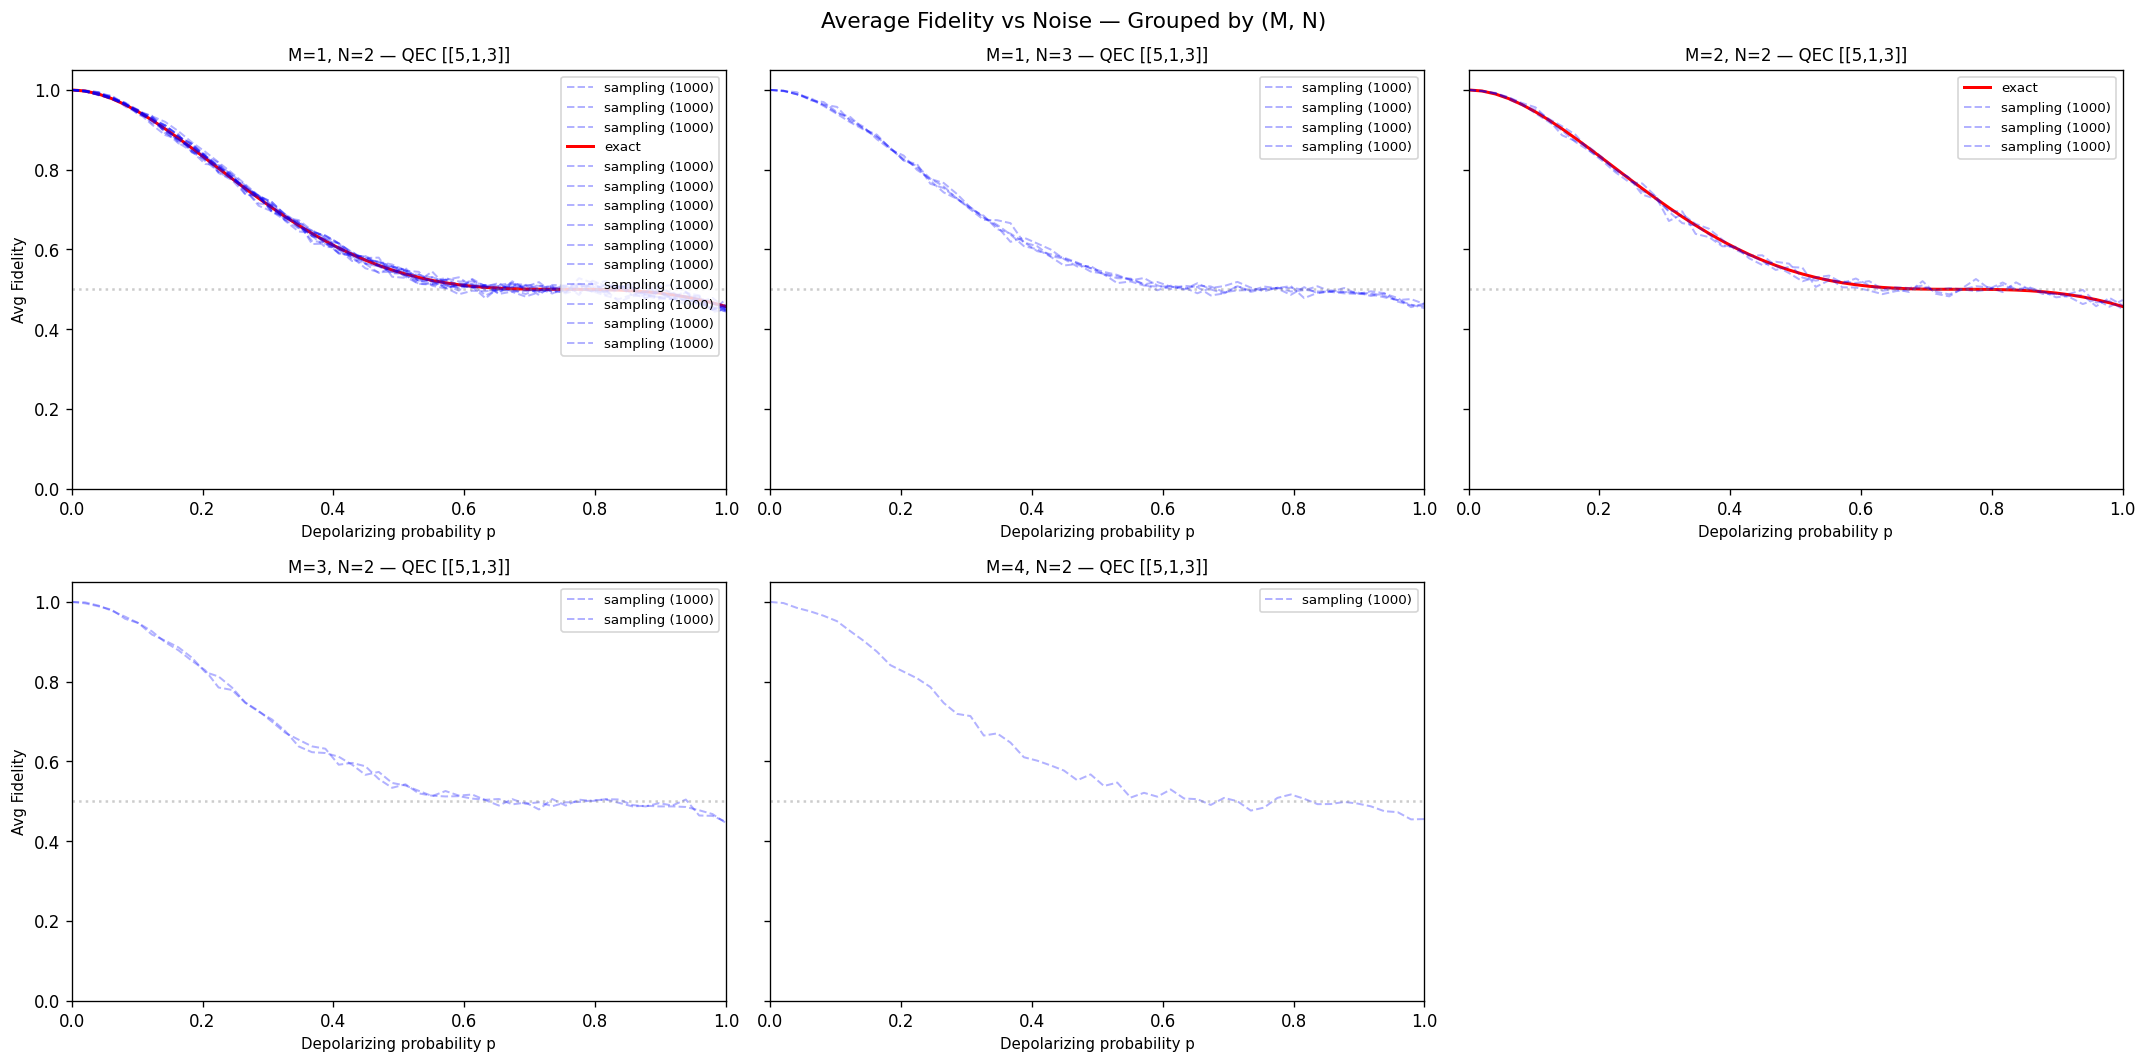

In [11]:
# --- QEC vs no-QEC overlay: same M, N across runs ---
# Compares runs that share the same (M, N) but differ in use_qec or mode.
# Exact runs: red solid line, alpha=1 (one per panel)
# Sampling runs: blue lines, alpha=0.6 (all shown)

from collections import defaultdict

groups = defaultdict(list)
for r in runs:
    if r["use_qec"] and r["N"] >= 2:
        groups[(r["M"], r["N"])].append(r)

pairs = {k: v for k, v in groups.items() if len(v) >= 1}

if not pairs:
    print("No runs to compare.")
else:
    n_groups = len(pairs)
    ncols = min(n_groups, 3)
    nrows = int(np.ceil(n_groups / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows),
                             squeeze=False, sharey=True)

    for gidx, ((M, N), group_runs) in enumerate(sorted(pairs.items())):
        ax = axes[gidx // ncols][gidx % ncols]

        exact_plotted = False
        for run in group_runs:
            try:
                p_arr = get_p_list(run)
            except KeyError:
                continue

            mode = run.get("metadata", {}).get("mode", "?").lower()
            is_exact = "exact" in mode
            is_sampling = "sampl" in mode

            if is_exact:
                if exact_plotted:
                    continue  # only one exact run per panel
                ax.plot(p_arr, np.array(run["fidelities"]).mean(axis=1),
                        linestyle="-", color="red", linewidth=1.8,
                        alpha=1.0, label="exact")
                exact_plotted = True
            elif is_sampling:
                n_samples = run.get("metadata", {}).get("n_samples", "?")
                ax.plot(p_arr, np.array(run["fidelities"]).mean(axis=1),
                        linestyle="--", color="blue", linewidth=1.2,
                        alpha=0.3, label=f"sampling ({n_samples})")
            else:
                # Fallback for unknown modes
                ax.plot(p_arr, np.array(run["fidelities"]).mean(axis=1),
                        linestyle=":", color="gray", linewidth=1.0,
                        alpha=0.6, label=mode)

        ax.axhline(0.5, color="gray", linestyle=":", alpha=0.4)
        ax.set_ylim(0, 1.05)
        ax.set_xlim(0, 1)
        ax.set_xlabel("Depolarizing probability p", fontsize=9)
        if gidx % ncols == 0:
            ax.set_ylabel("Avg Fidelity", fontsize=9)
        ax.legend(fontsize=8, loc="upper right")
        ax.set_title(f"M={M}, N={N} — QEC [[5,1,3]]", fontsize=10)

    for idx in range(n_groups, nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.suptitle("Average Fidelity vs Noise — Grouped by (M, N)", fontsize=13)
    plt.tight_layout()
    plt.show()
